In [91]:
import numpy as np 
import pandas as pd
pd.set_option('display.max_columns',None)

In [92]:
train_data = pd.read_csv('train.csv')
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [93]:
#separating the categorical features and numerical features
num_cols = list(set(train_data.describe().columns.to_list()) - set(['Id']))
cat_cols = list(set(train_data.columns.to_list()) - set(num_cols) - set(['Id']))

In [94]:
len(num_cols)

37

array([[<Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'MoSold'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': '1stFlrSF'}>],
       [<Axes: title={'center': 'GarageYrBlt'}>,
        <Axes: title={'center': 'TotRmsAbvGrd'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'MSSubClass'}>],
       [<Axes: title={'center': 'GarageArea'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'YrSold'}>,
        <Axes: title={'center': 'OverallQual'}>],
       [<Axes: title={'center': 'EnclosedPorch'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'OpenPorchSF'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'WoodDeckSF'}>, <Axes: >]], dtype=object)

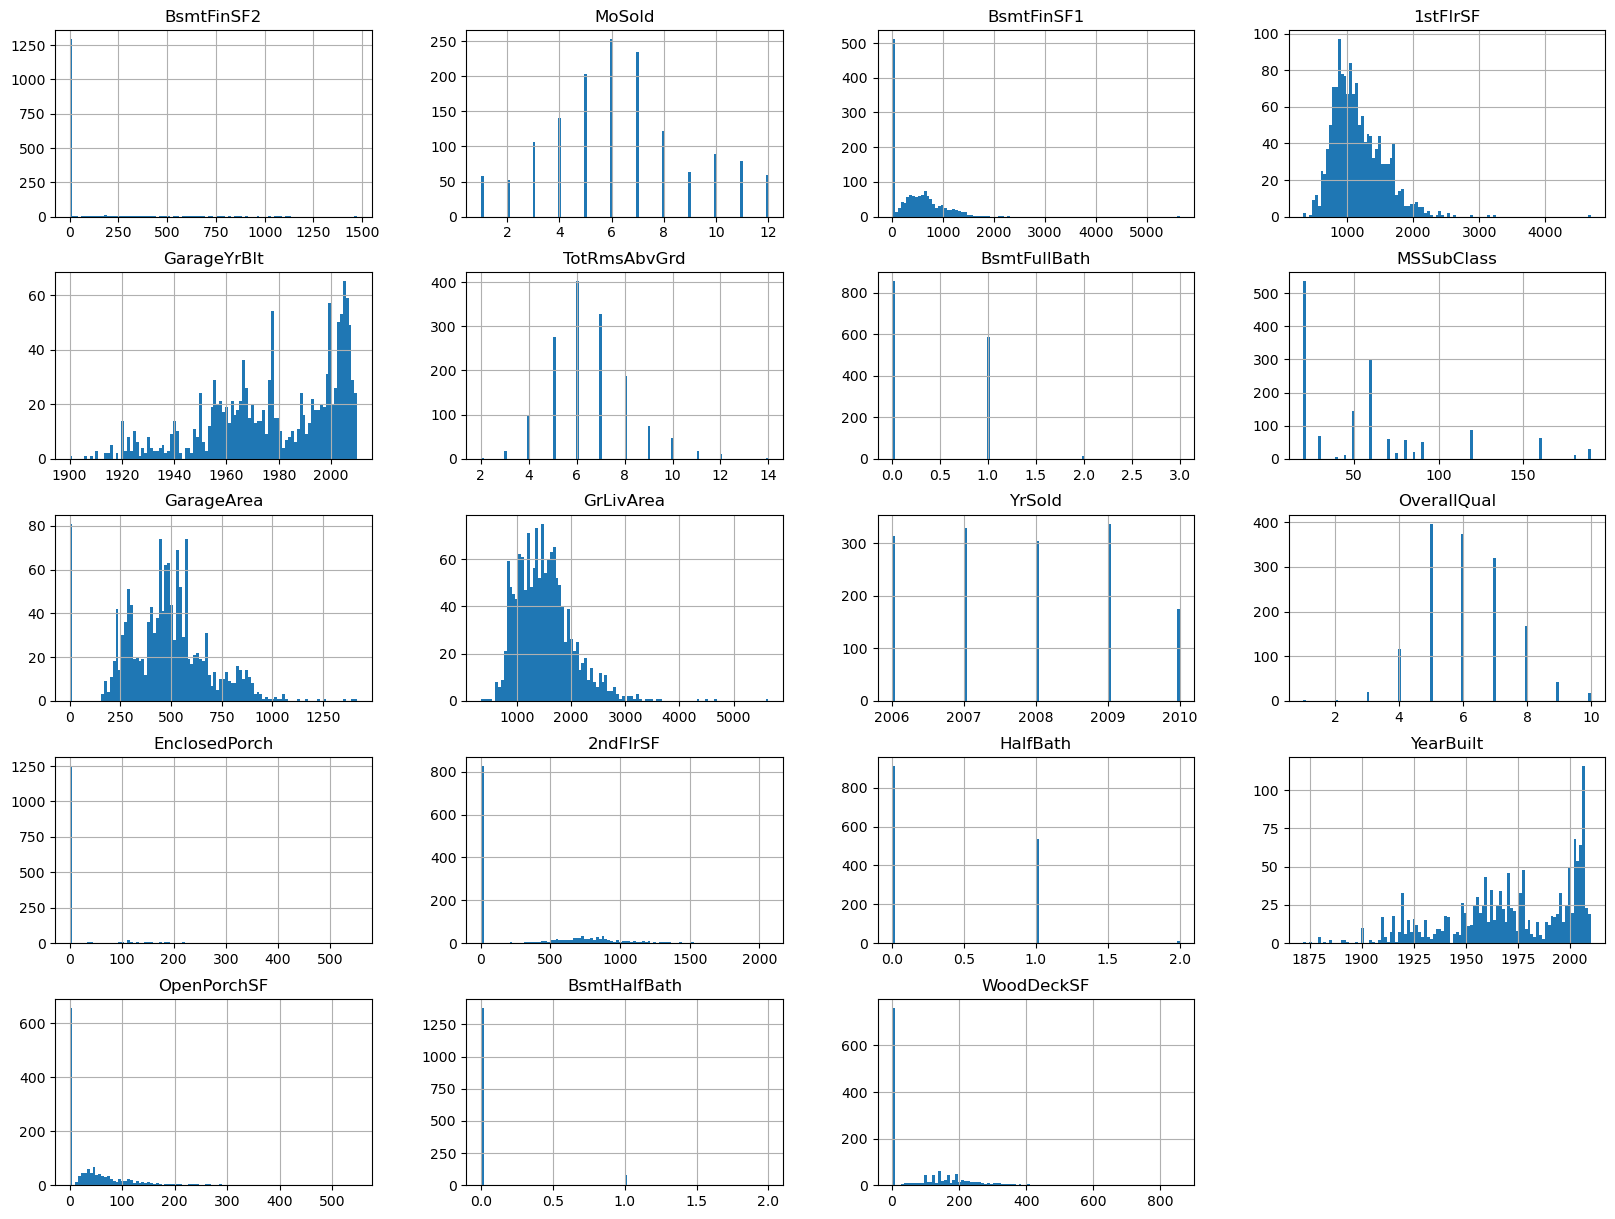

In [95]:
import matplotlib.pyplot as plt
train_data[num_cols[:19]].hist(bins=100,figsize=(20,15))

array([[<Axes: title={'center': 'MiscVal'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'GarageCars'}>,
        <Axes: title={'center': 'Fireplaces'}>],
       [<Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'ScreenPorch'}>,
        <Axes: title={'center': 'KitchenAbvGr'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'SalePrice'}>,
        <Axes: title={'center': 'BedroomAbvGr'}>,
        <Axes: title={'center': 'LotFrontage'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'PoolArea'}>,
        <Axes: title={'center': '3SsnPorch'}>,
        <Axes: title={'center': 'LowQualFinSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

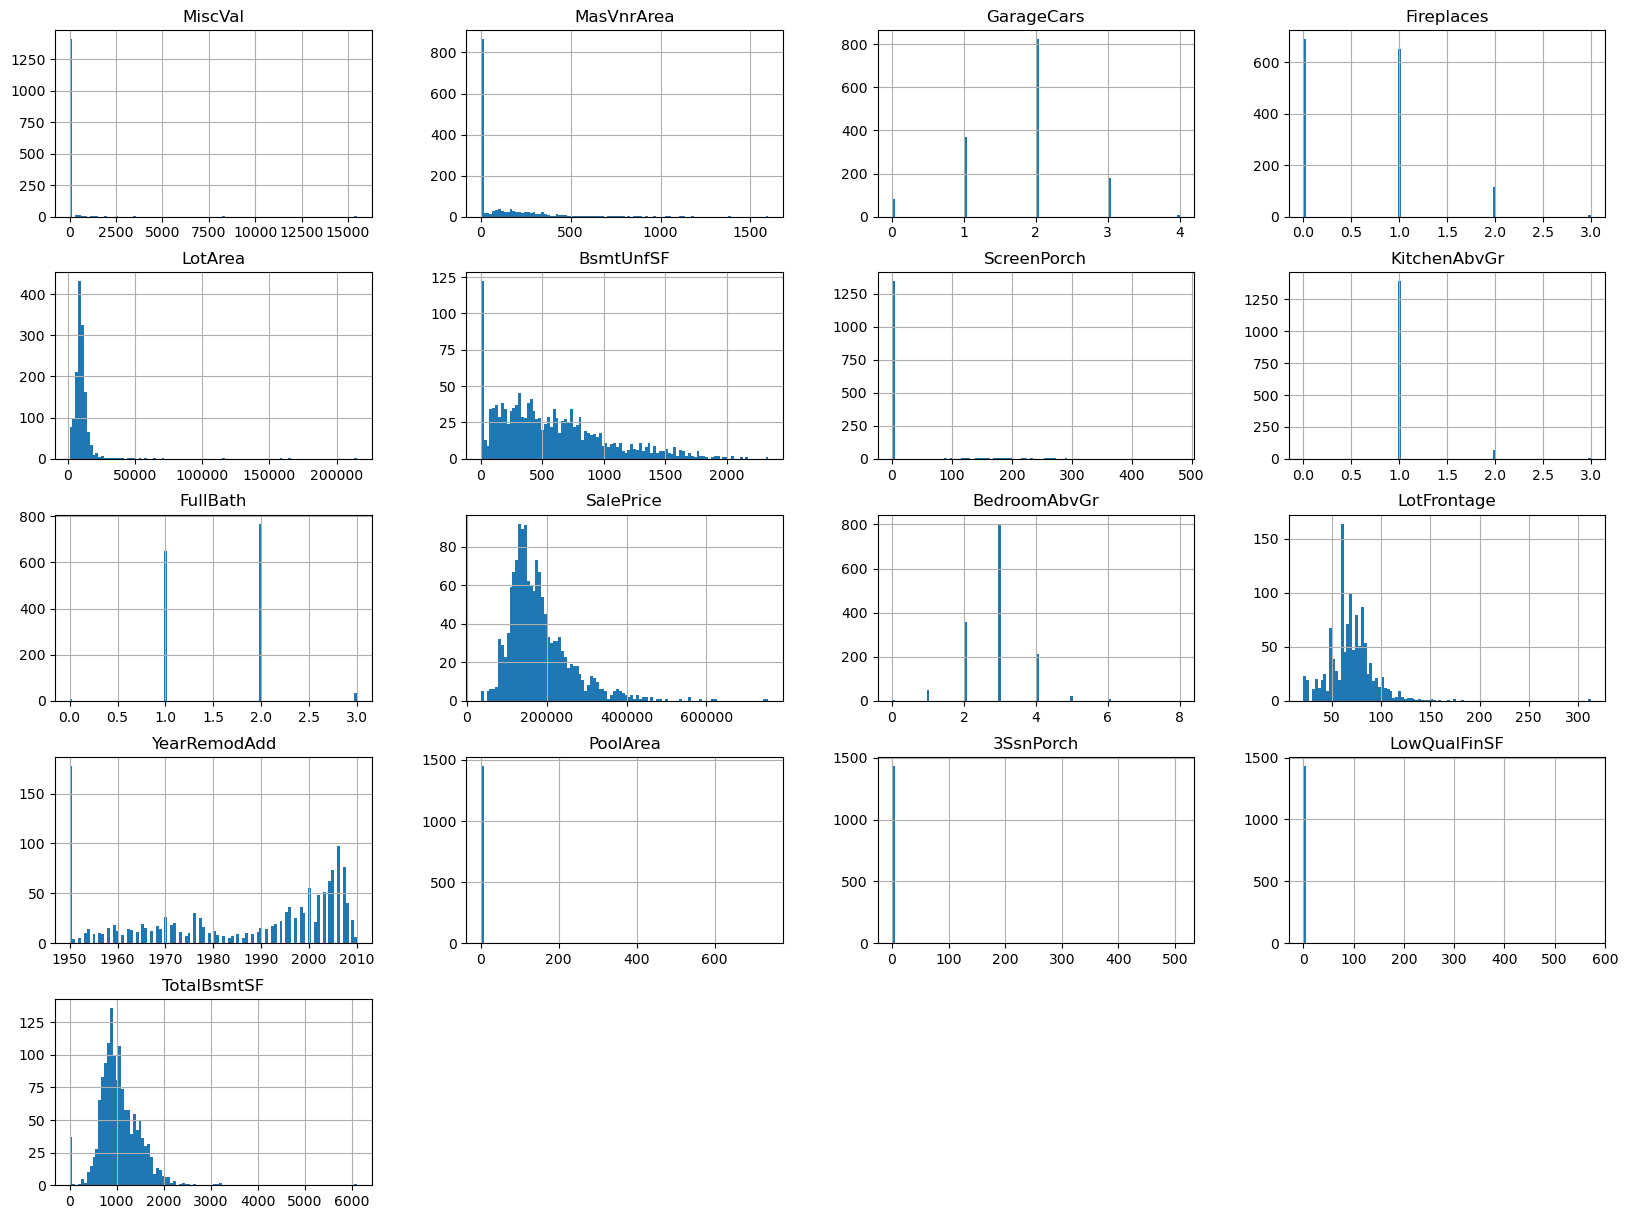

In [96]:
train_data[num_cols[20:]].hist(bins = 100, figsize = (20, 15))

In [97]:
corr_matrix = train_data[num_cols].corr()
corr_matrix

,BsmtFinSF2,MoSold,BsmtFinSF1,1stFlrSF,GarageYrBlt,TotRmsAbvGrd,BsmtFullBath,MSSubClass,GarageArea,GrLivArea,YrSold,OverallQual,EnclosedPorch,2ndFlrSF,HalfBath,YearBuilt,OpenPorchSF,BsmtHalfBath,WoodDeckSF,OverallCond,MiscVal,MasVnrArea,GarageCars,Fireplaces,LotArea,BsmtUnfSF,ScreenPorch,KitchenAbvGr,FullBath,SalePrice,BedroomAbvGr,LotFrontage,YearRemodAdd,PoolArea,3SsnPorch,LowQualFinSF,TotalBsmtSF
BsmtFinSF2,1.000000,-0.015211,-0.050117,0.097117,-0.088011,-0.035227,0.158678,-0.065649,-0.018227,-0.009640,0.031706,-0.059119,0.036543,-0.099260,-0.032148,-0.049107,0.003093,0.070948,0.067898,0.040229,0.004940,-0.072319,-0.038264,0.046921,0.111170,-0.209294,0.088871,-0.040751,-0.076444,-0.011378,-0.015728,0.049900,-0.067759,0.041709,-0.029993,0.014807,0.104810
MoSold,-0.015211,1.000000,-0.015727,0.031372,0.005337,0.036907,-0.025361,-0.013585,0.027974,0.050240,-0.145721,0.070815,-0.028887,0.035164,-0.009050,0.012398,0.071255,0.032873,0.021011,-0.003511,-0.006495,-0.005965,0.040522,0.046357,0.001205,0.034888,0.023217,0.026589,0.055872,0.046432,0.046544,0.011200,0.021490,-0.033737,0.029474,-0.022174,0.013196
BsmtFinSF1,-0.050117,-0.015727,1.000000,0.445863,0.153484,0.044316,0.649212,-0.069836,0.296970,0.208171,0.014359,0.239666,-0.102303,-0.137079,0.004262,0.249503,0.111761,0.067418,0.204306,-0.046231,0.003571,0.264736,0.224054,0.260011,0.214103,-0.495251,0.062021,-0.081007,0.058543,0.386420,-0.107355,0.233633,0.128451,0.140491,0.026451,-0.064503,0.522396
1stFlrSF,0.097117,0.031372,0.445863,1.000000,0.233449,0.409516,0.244671,-0.251758,0.489782,0.566024,-0.013604,0.476224,-0.065292,-0.202646,-0.119916,0.281986,0.211671,0.001956,0.235459,-0.144203,-0.021096,0.344501,0.439317,0.410531,0.299475,0.317987,0.088758,0.068101,0.380637,0.605852,0.127401,0.457181,0.240379,0.131525,0.056104,-0.014241,0.819530
GarageYrBlt,-0.088011,0.005337,0.153484,0.233449,1.000000,0.148112,0.124553,0.085072,0.564567,0.231197,-0.001014,0.547766,-0.297003,0.070832,0.196785,0.825667,0.228425,-0.077464,0.224577,-0.324297,-0.032417,0.252691,0.588920,0.046822,-0.024947,0.190708,-0.075418,-0.124411,0.484557,0.486362,-0.064518,0.070250,0.642277,-0.014501,0.023544,-0.036363,0.322445
TotRmsAbvGrd,-0.035227,0.036907,0.044316,0.409516,0.148112,1.000000,-0.053275,0.040380,0.337822,0.825489,-0.034516,0.427452,0.004151,0.616423,0.343415,0.095589,0.234192,-0.023836,0.165984,-0.057583,0.024763,0.280682,0.362289,0.326114,0.190015,0.250647,0.059383,0.256045,0.554784,0.533723,0.676620,0.352096,0.191740,0.083757,-0.006683,0.131185,0.285573
BsmtFullBath,0.158678,-0.025361,0.649212,0.244671,0.124553,-0.053275,1.000000,0.003491,0.179189,0.034836,0.067049,0.111098,-0.049911,-0.169494,-0.030905,0.187599,0.067341,-0.147871,0.175315,-0.054942,-0.023047,0.085310,0.131881,0.137928,0.158155,-0.422900,0.023148,-0.041503,-0.064512,0.227122,-0.150673,0.100949,0.119470,0.067616,-0.000106,-0.047143,0.307351
MSSubClass,-0.065649,-0.013585,-0.069836,-0.251758,0.085072,0.040380,0.003491,1.000000,-0.098672,0.074853,-0.021407,0.032628,-0.012037,0.307886,0.177354,0.027850,-0.006100,-0.002333,-0.012579,-0.059316,-0.007683,0.022936,-0.040110,-0.045569,-0.139781,-0.140759,-0.026030,0.281721,0.131608,-0.084284,-0.023438,-0.386347,0.040581,0.008283,-0.043825,0.046474,-0.238518
GarageArea,-0.018227,0.027974,0.296970,0.489782,0.564567,0.337822,0.179189,-0.098672,1.000000,0.468997,-0.027378,0.562022,-0.121777,0.138347,0.163549,0.478954,0.241435,-0.024536,0.224666,-0.151521,-0.027400,0.373066,0.882475,0.269141,0.180403,0.183303,0.051412,-0.064433,0.405656,0.623431,0.065253,0.344997,0.371600,0.061047,0.035087,-0.067601,0.486665
GrLivArea,-0.009640,0.050240,0.208171,0.566024,0.231197,0.825489,0.034836,0.074853,0.468997,1.000000,-0.036526,0.593007,0.009113,0.687501,0.415772,0.199010,0.330224,-0.018918,0.247433,-0.079686,-0.002416,0.390857,0.467247,0.461679,0.263116,0.240257,0.101510,0.100063,0.630012,0.708624,0.521270,0.402797,0.287389,0.170205,0.020643,0.134683,0.454868


<Axes: >

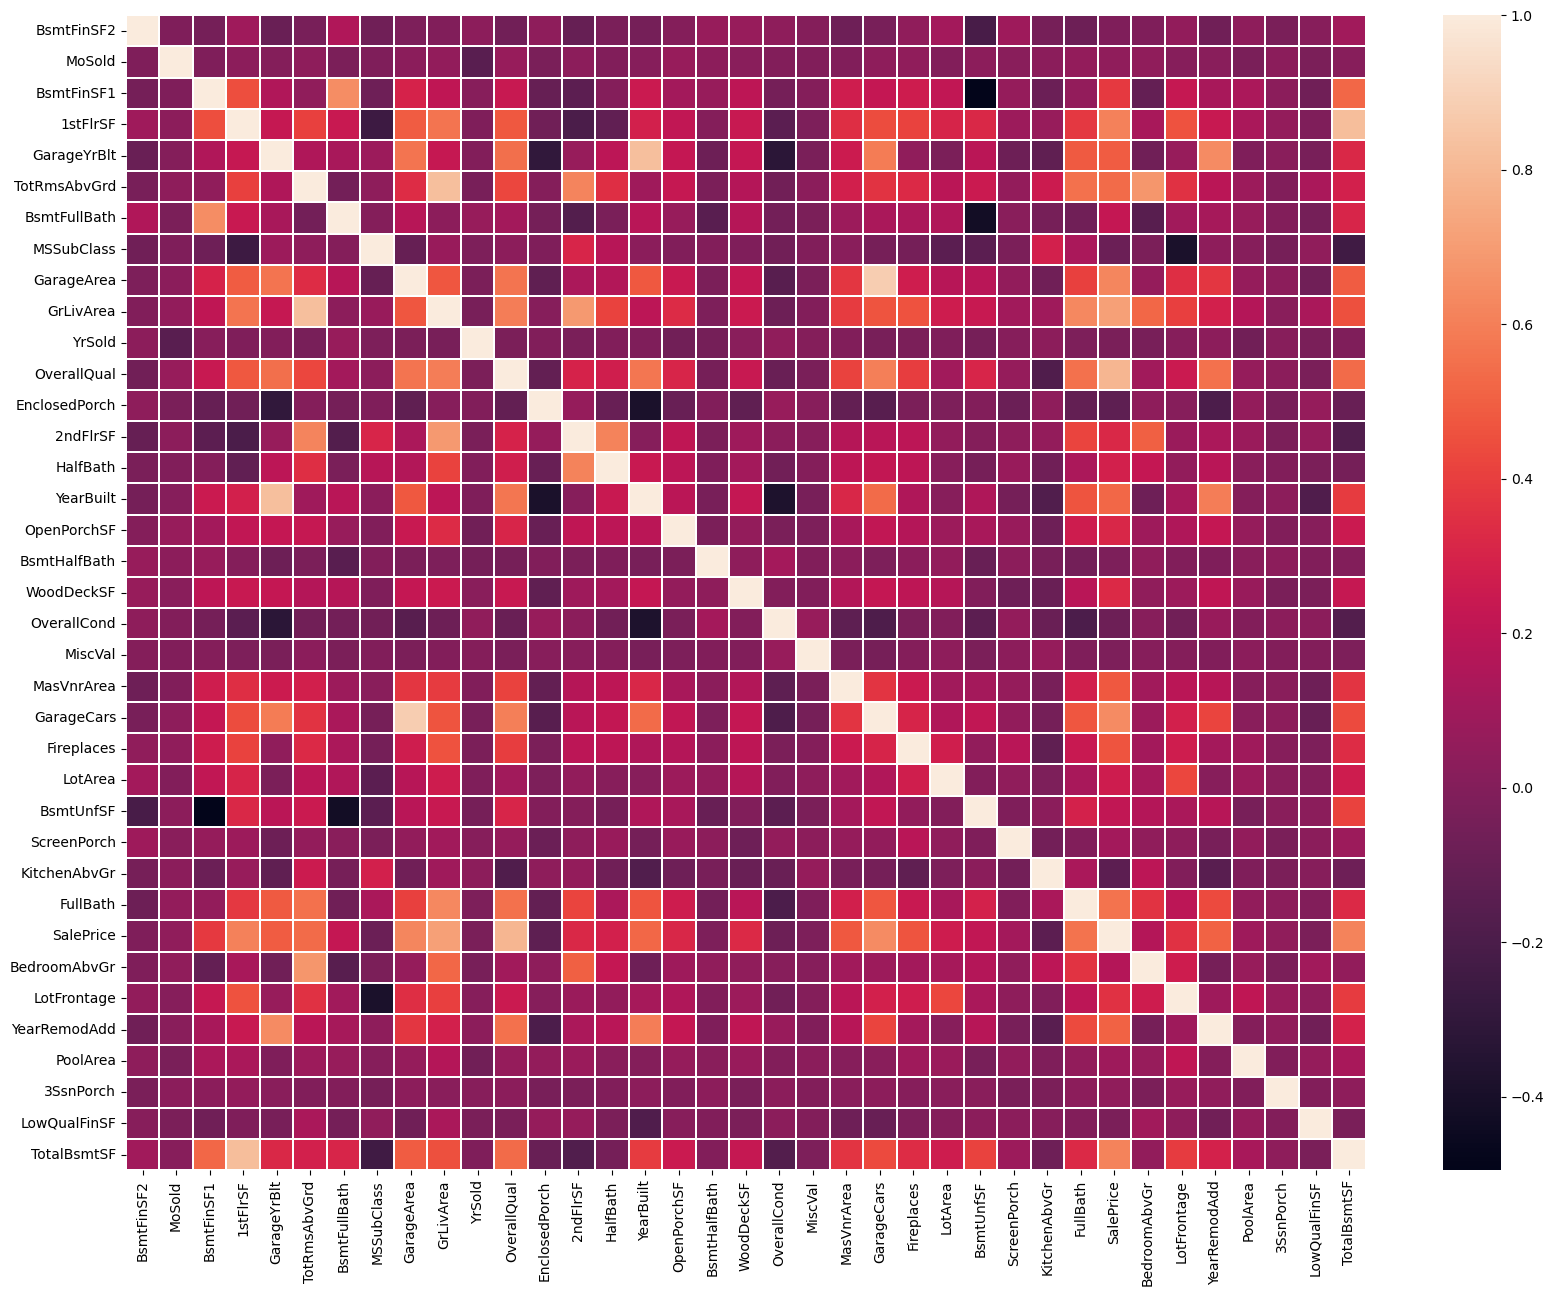

In [98]:
#heatmap
import seaborn as sns 
plt.subplots(figsize=(20,15))
sns.heatmap(corr_matrix,
           xticklabels = corr_matrix.columns.values,
           yticklabels = corr_matrix.columns.values,
           linewidth=0.1)

# Categorical Variables Visuals

In [99]:
df_list=[]
for cat_column in cat_cols:
    df_list.append(train_data.groupby([cat_column])['Id'].count().reset_index().rename(columns = {'Id' : 'count'}))
#     df_list.append(train_data[cat_column].value_counts().reset_index())
df_list

[  LotShape  count
 0      IR1    484
 1      IR2     41
 2      IR3     10
 3      Reg    925,
   MSZoning  count
 0  C (all)     10
 1       FV     65
 2       RH     16
 3       RL   1151
 4       RM    218,
   GarageFinish  count
 0          Fin    352
 1          RFn    422
 2          Unf    605,
   BsmtCond  count
 0       Fa     45
 1       Gd     65
 2       Po      2
 3       TA   1311,
   RoofStyle  count
 0      Flat     13
 1     Gable   1141
 2   Gambrel     11
 3       Hip    286
 4   Mansard      7
 5      Shed      2,
   GarageQual  count
 0         Ex      3
 1         Fa     48
 2         Gd     14
 3         Po      3
 4         TA   1311,
   SaleType  count
 0      COD     43
 1      CWD      4
 2      Con      2
 3    ConLD      9
 4    ConLI      5
 5    ConLw      5
 6      New    122
 7      Oth      3
 8       WD   1267,
   HouseStyle  count
 0     1.5Fin    154
 1     1.5Unf     14
 2     1Story    726
 3     2.5Fin      8
 4     2.5Unf     11
 5     2Story  

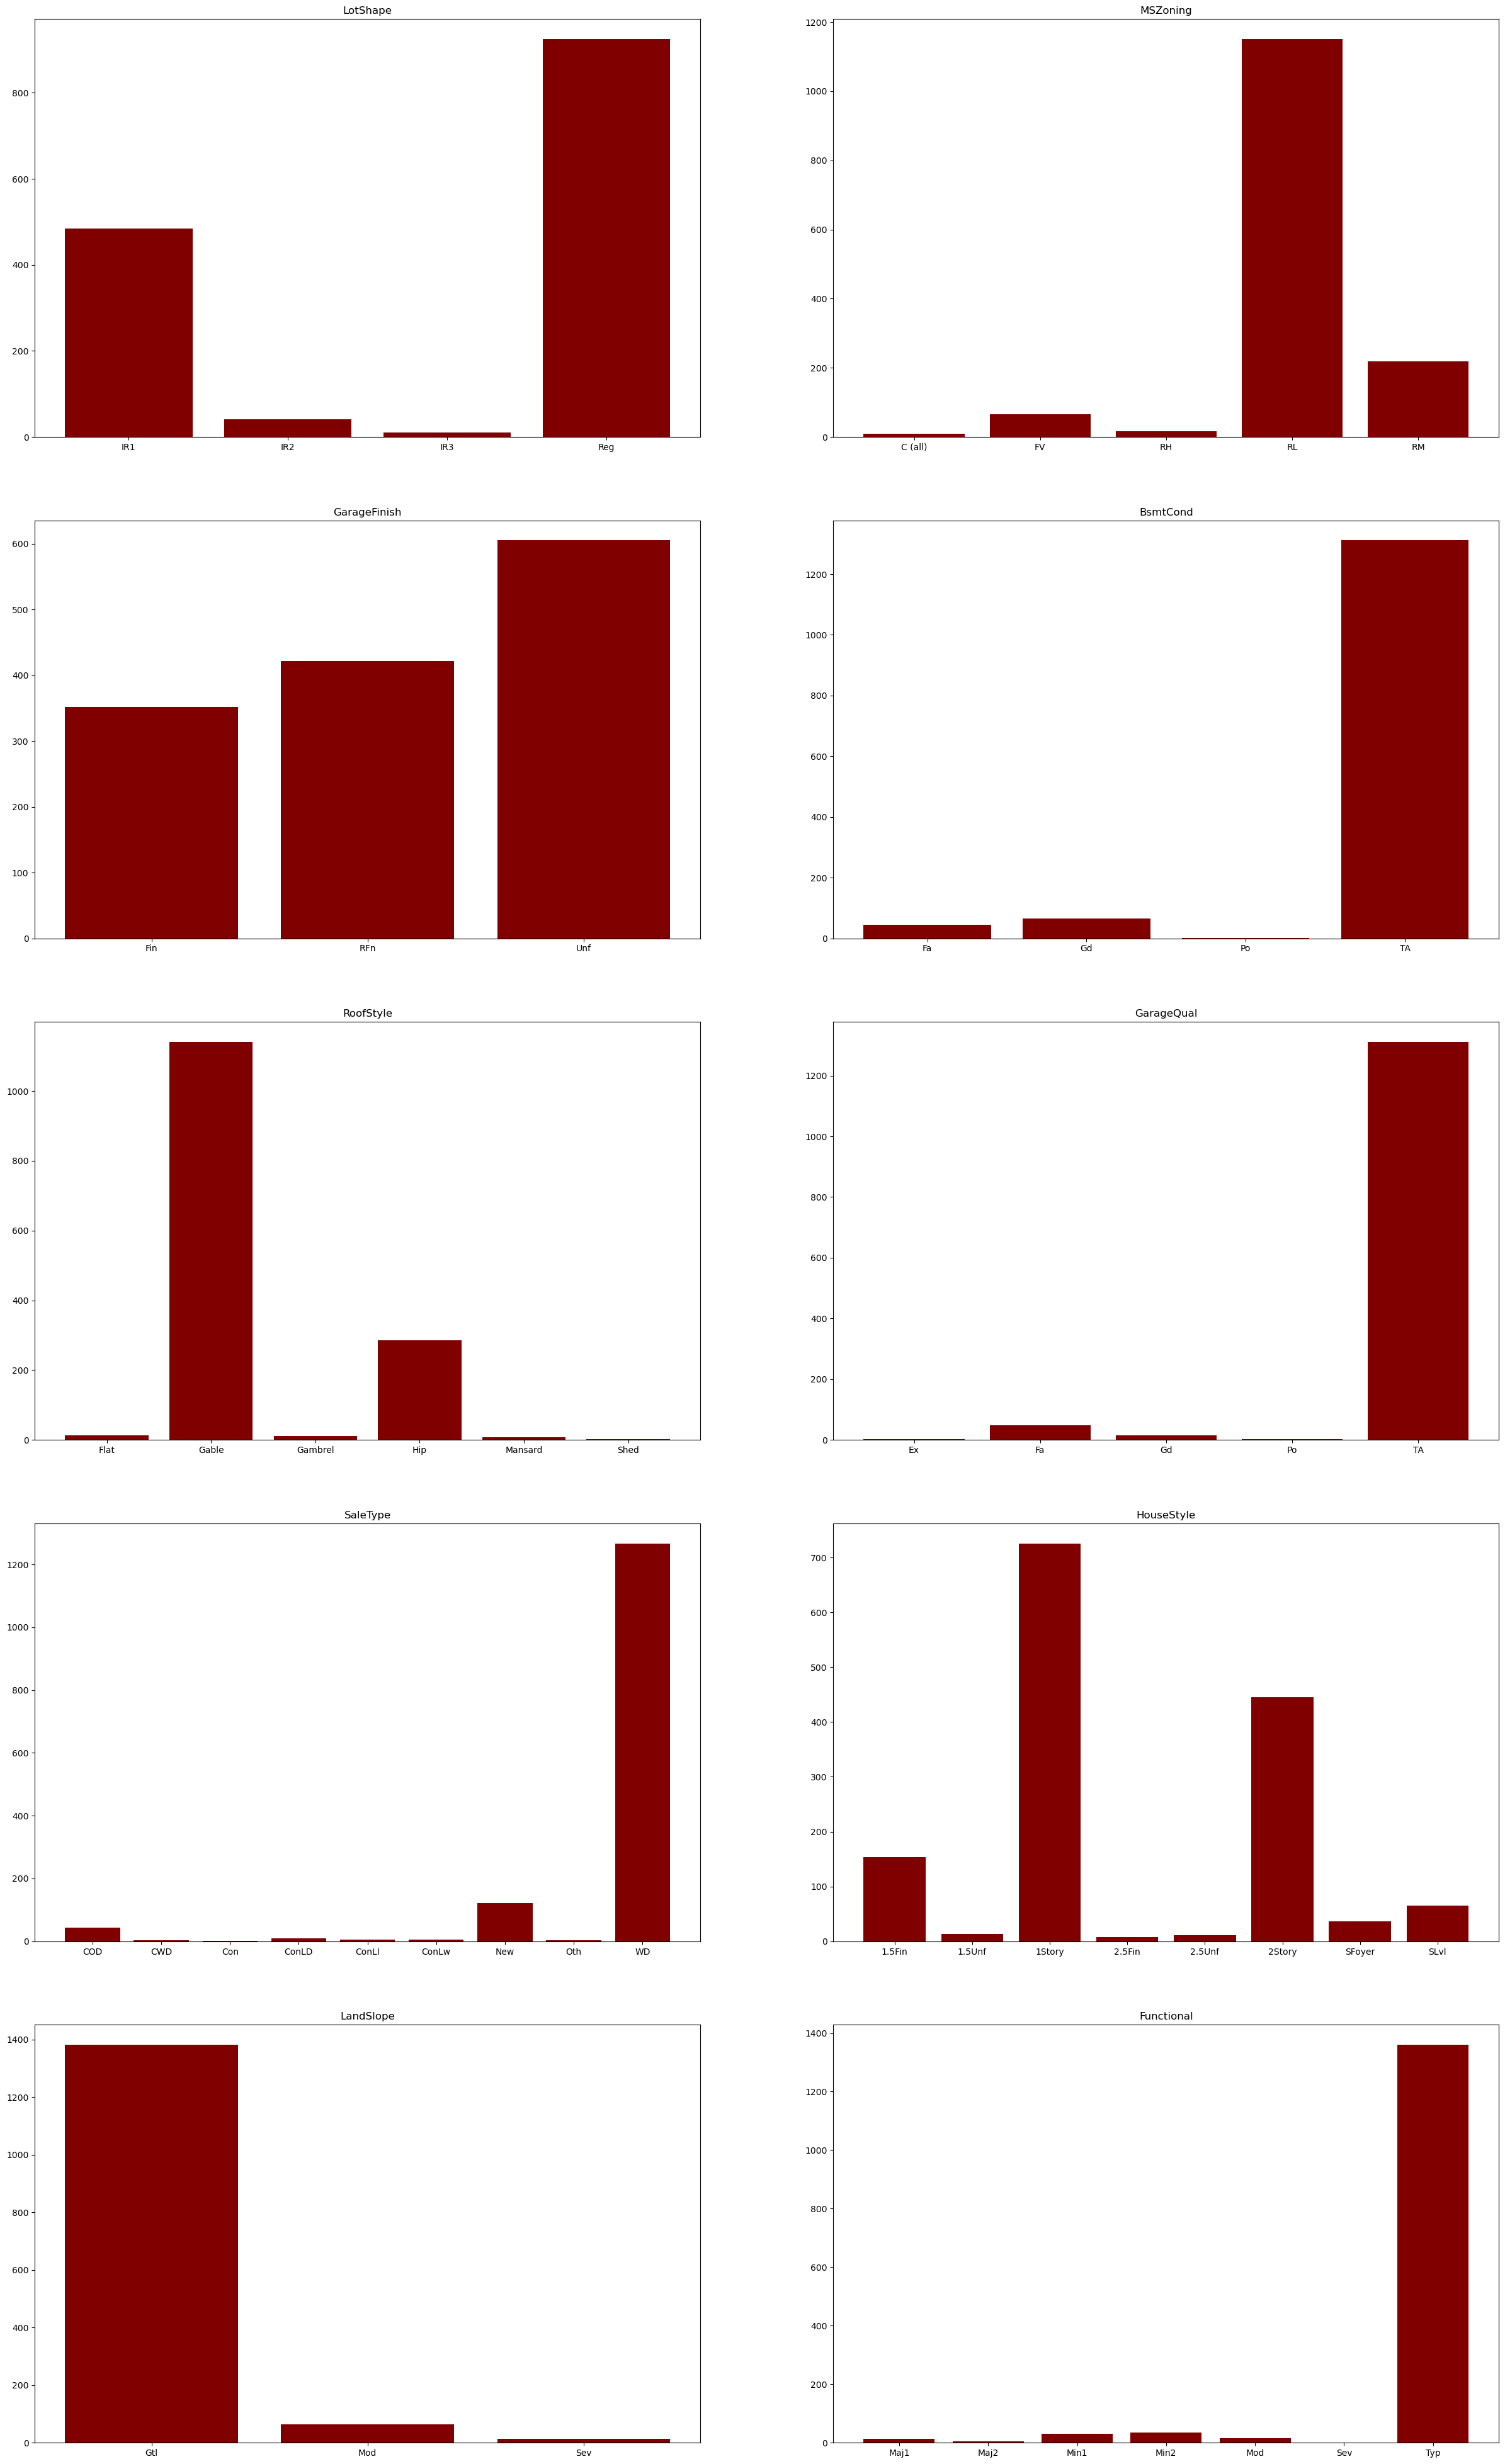

In [100]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[0:10]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

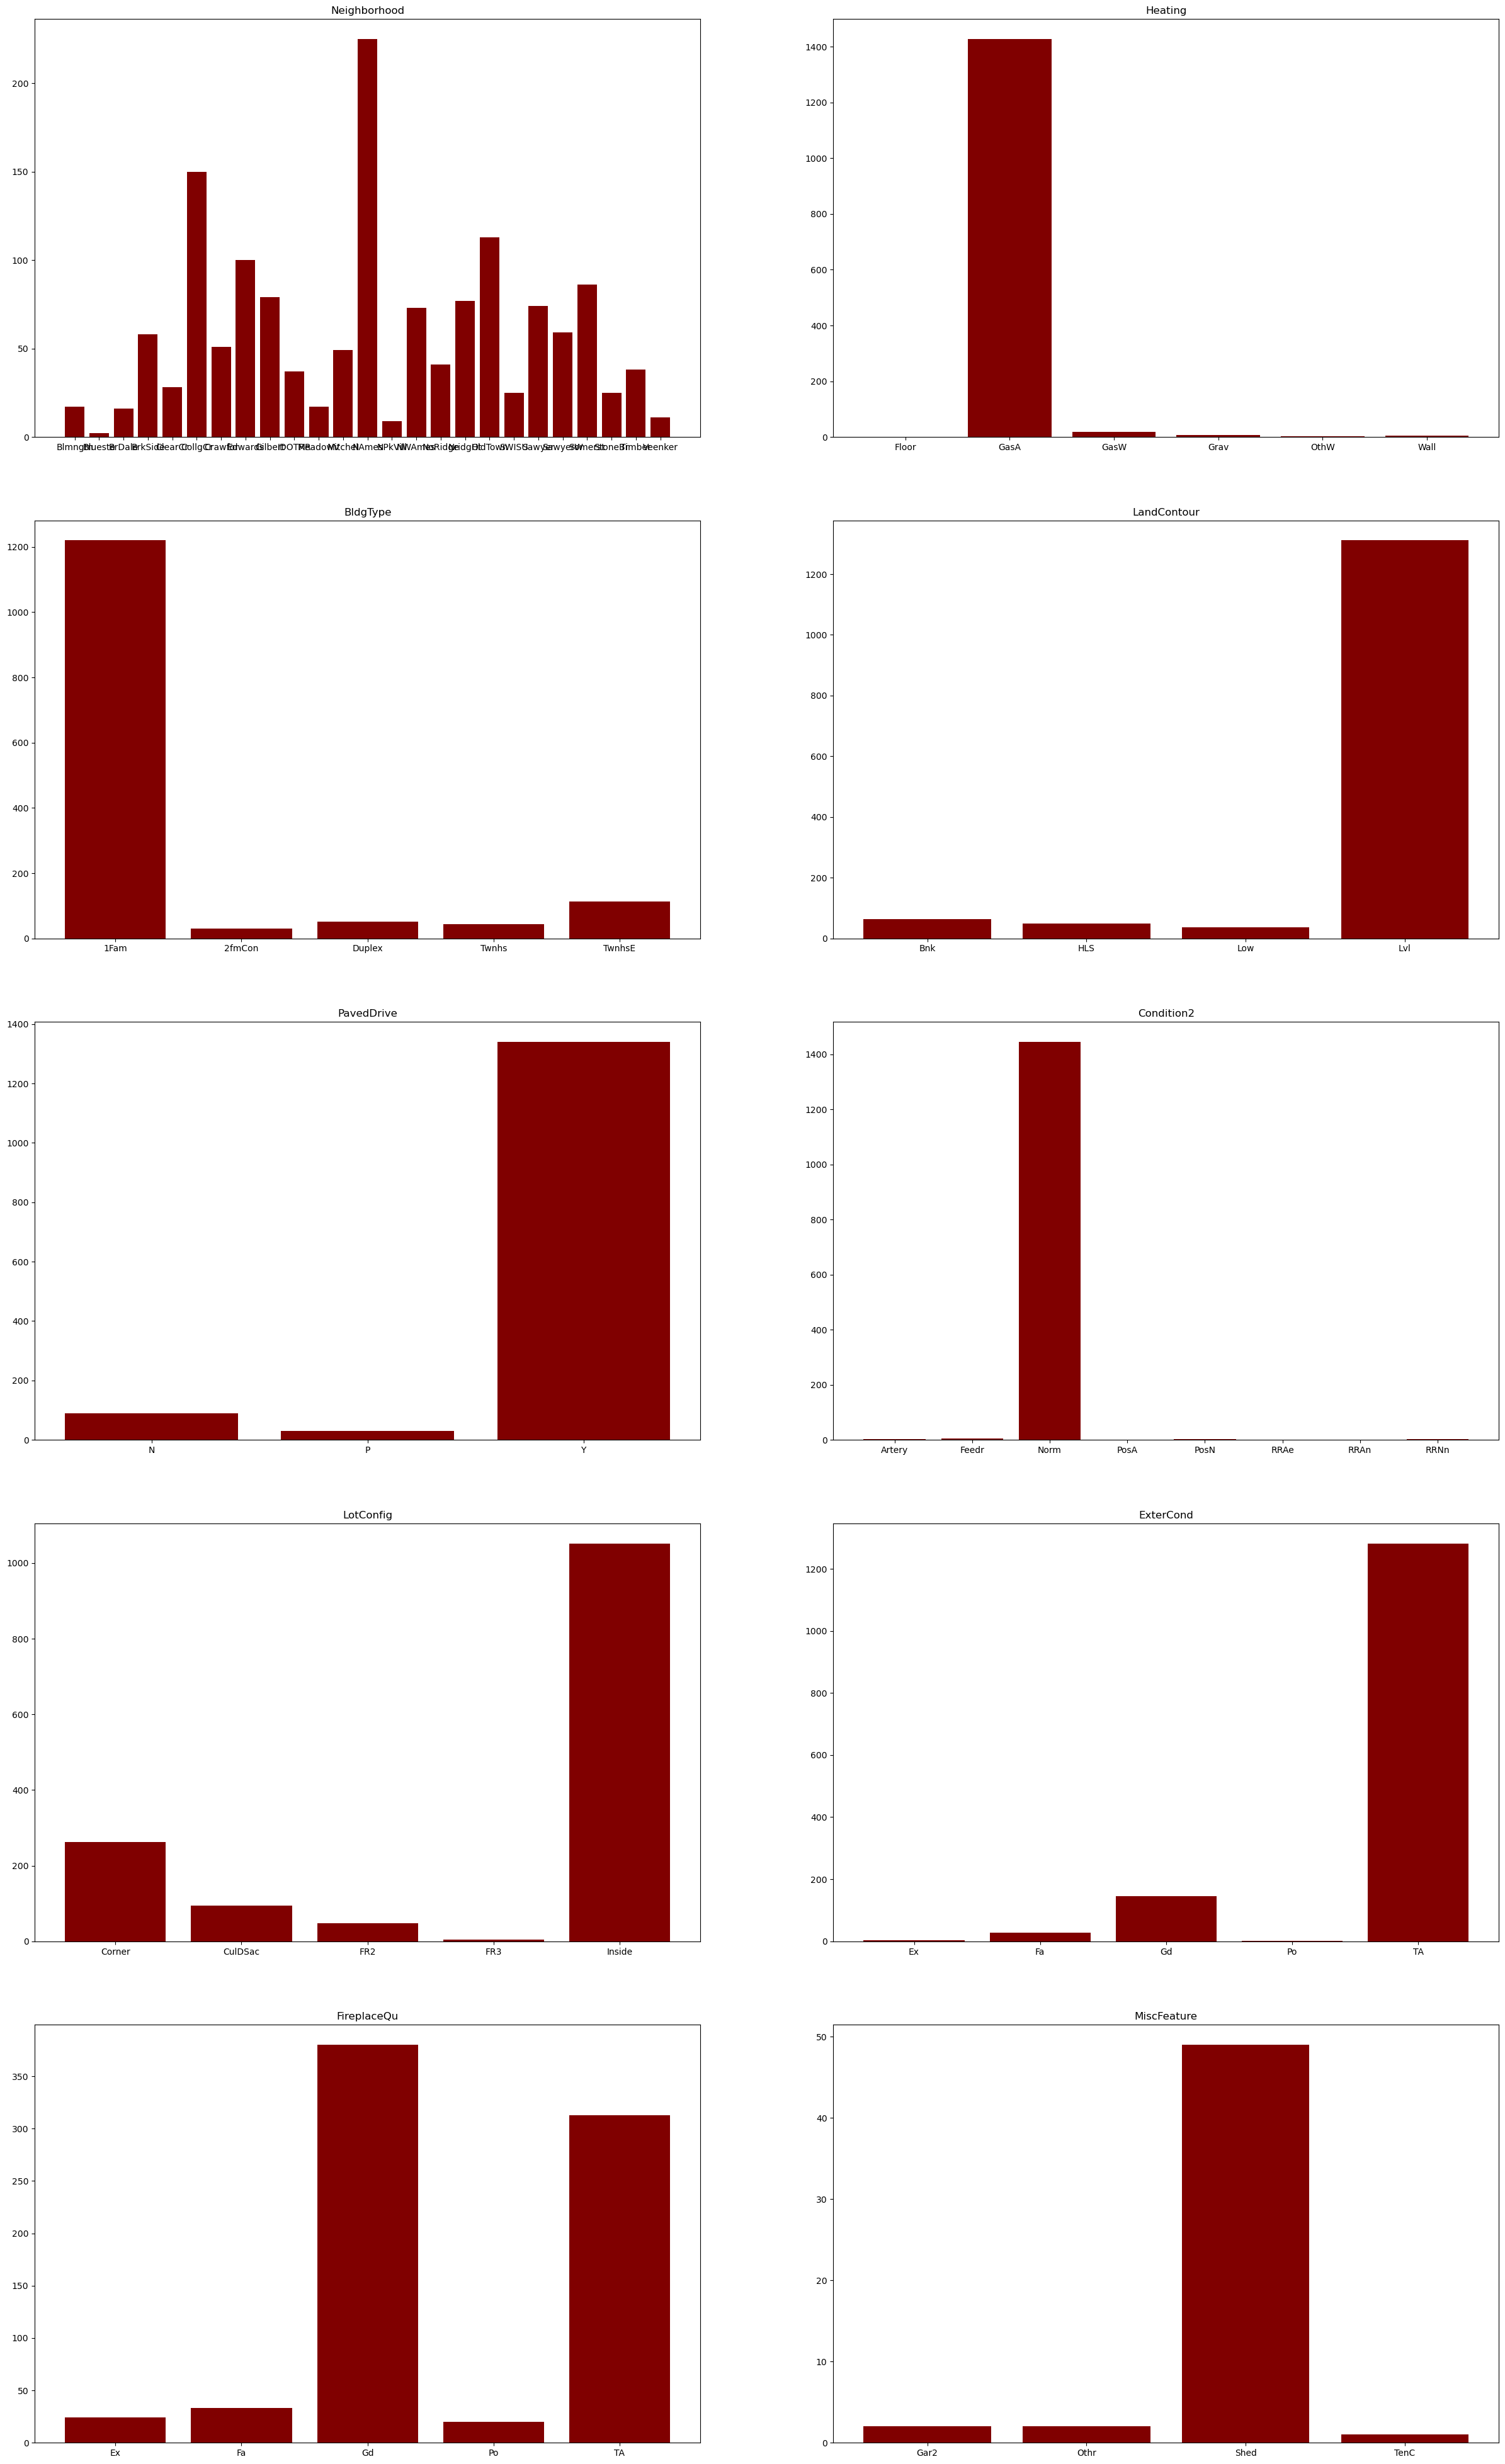

In [101]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[10:20]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

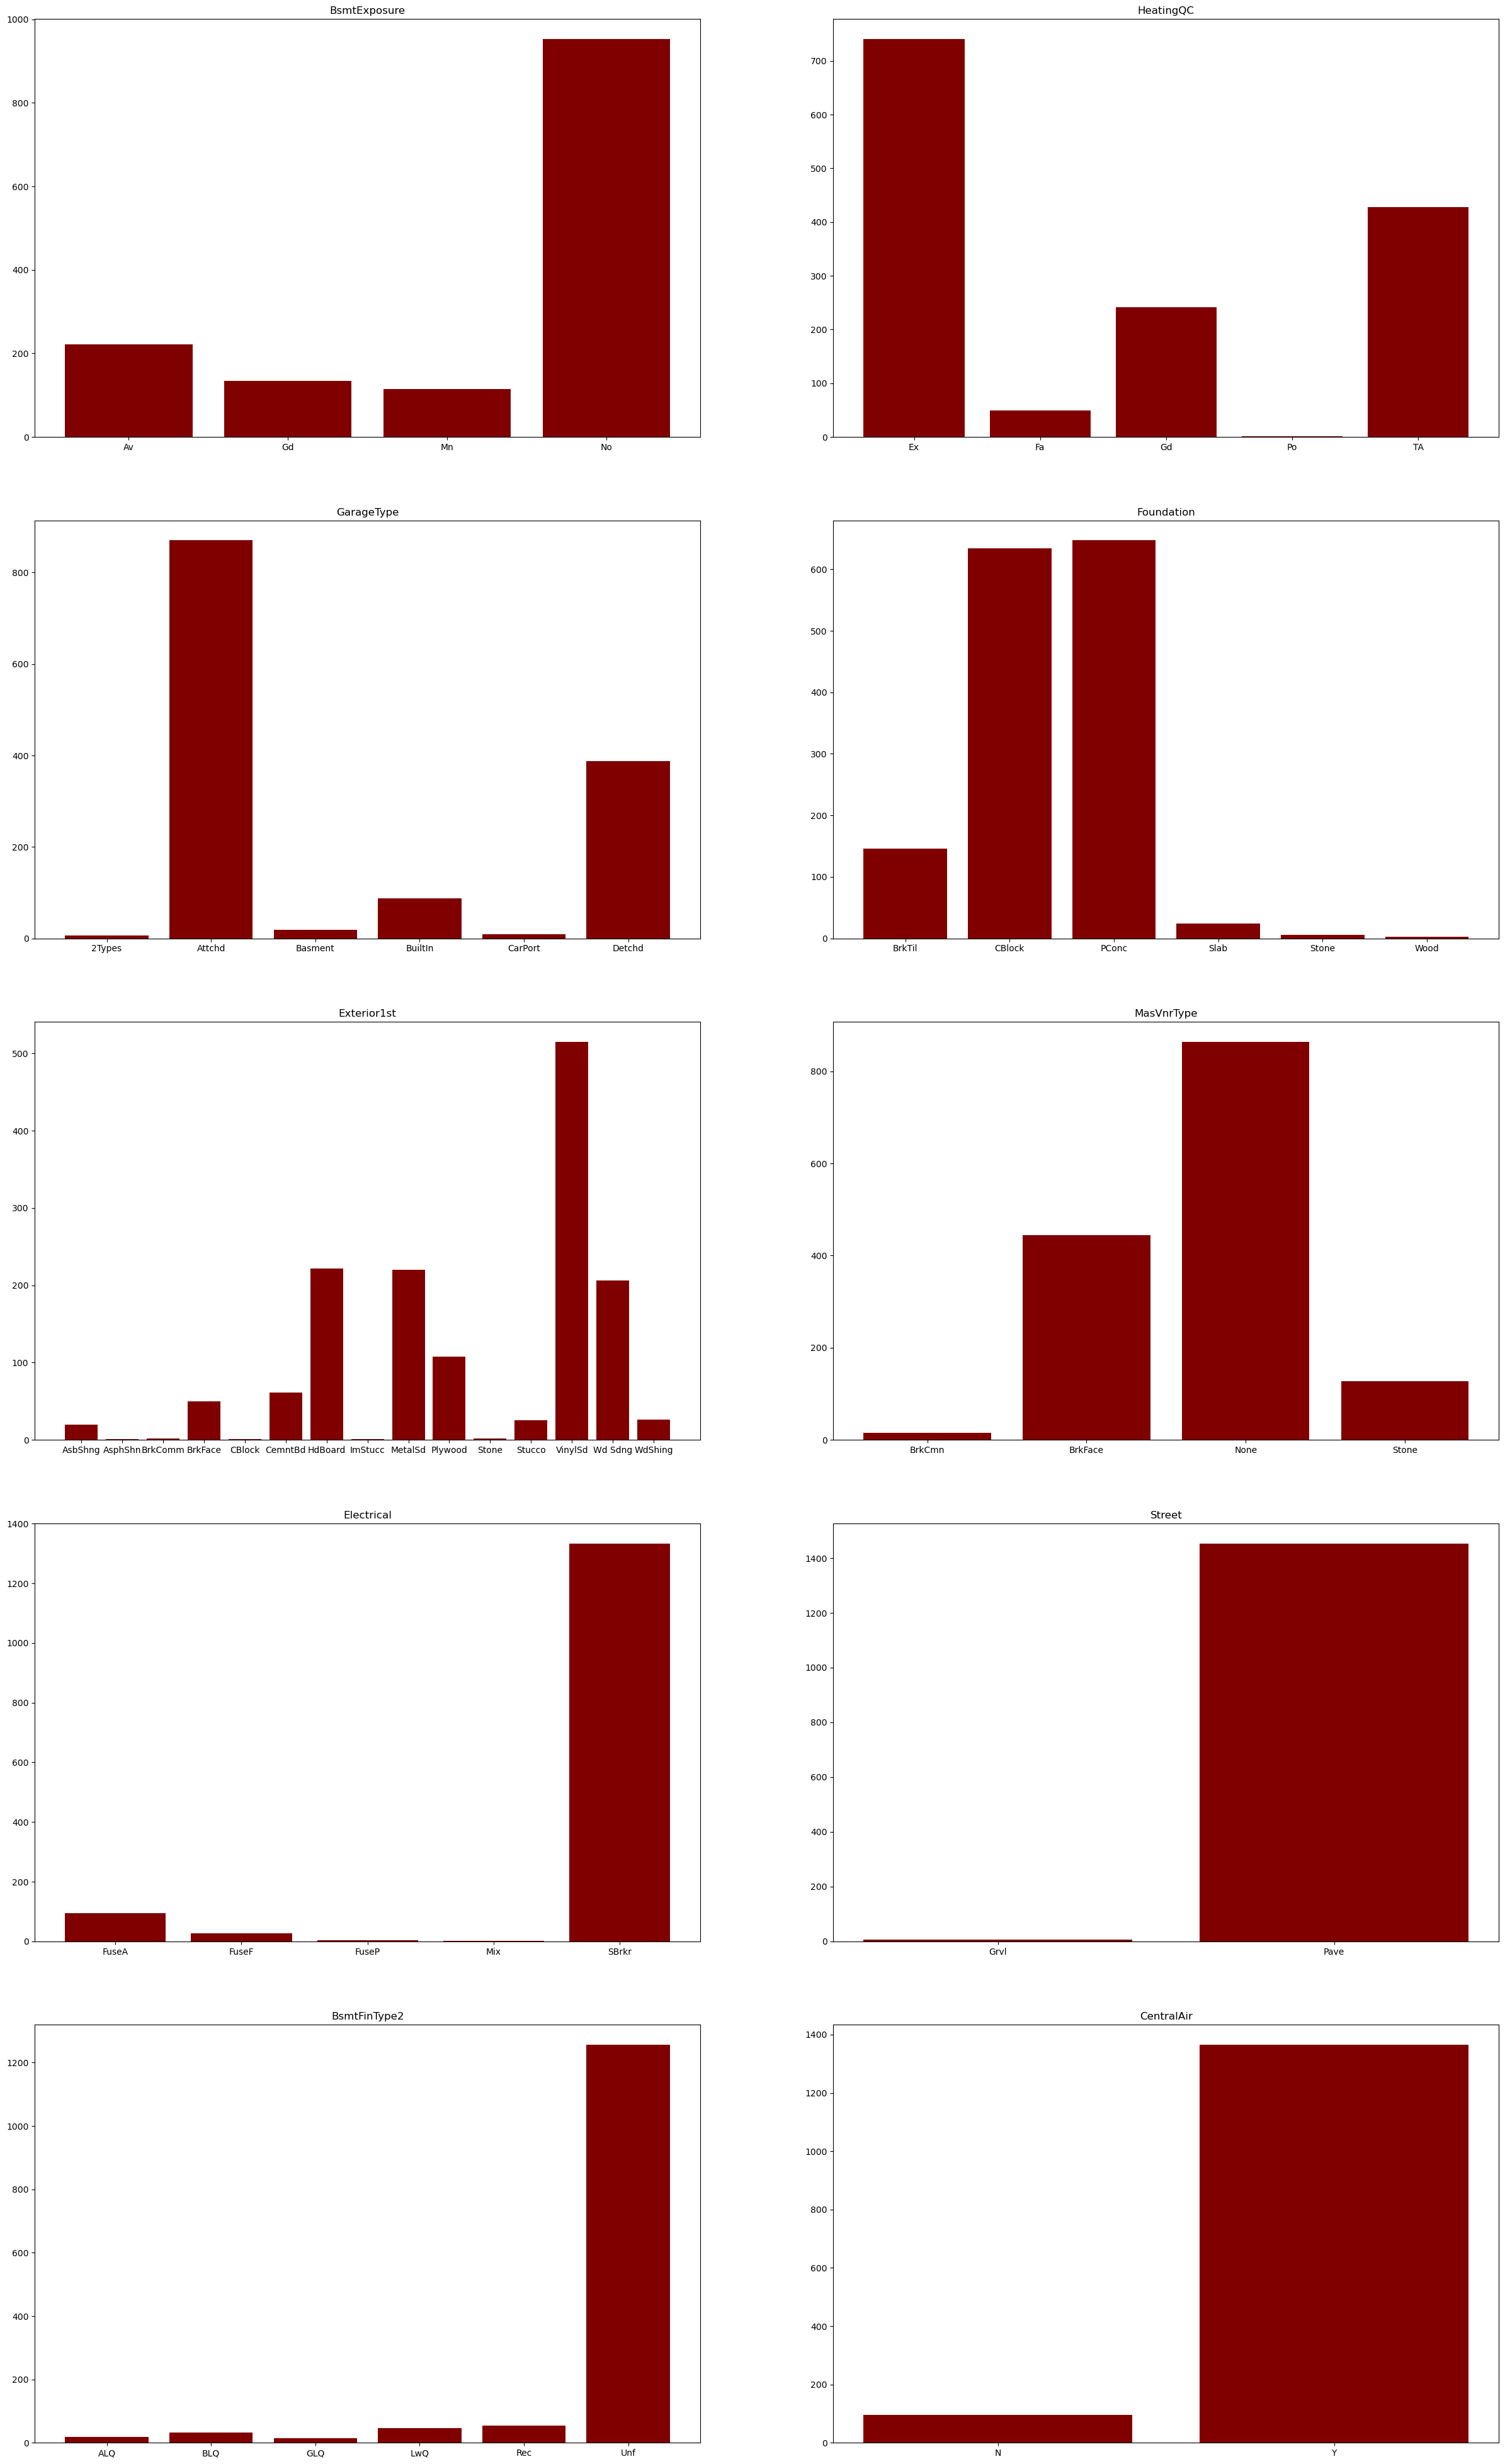

In [102]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[20:30]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

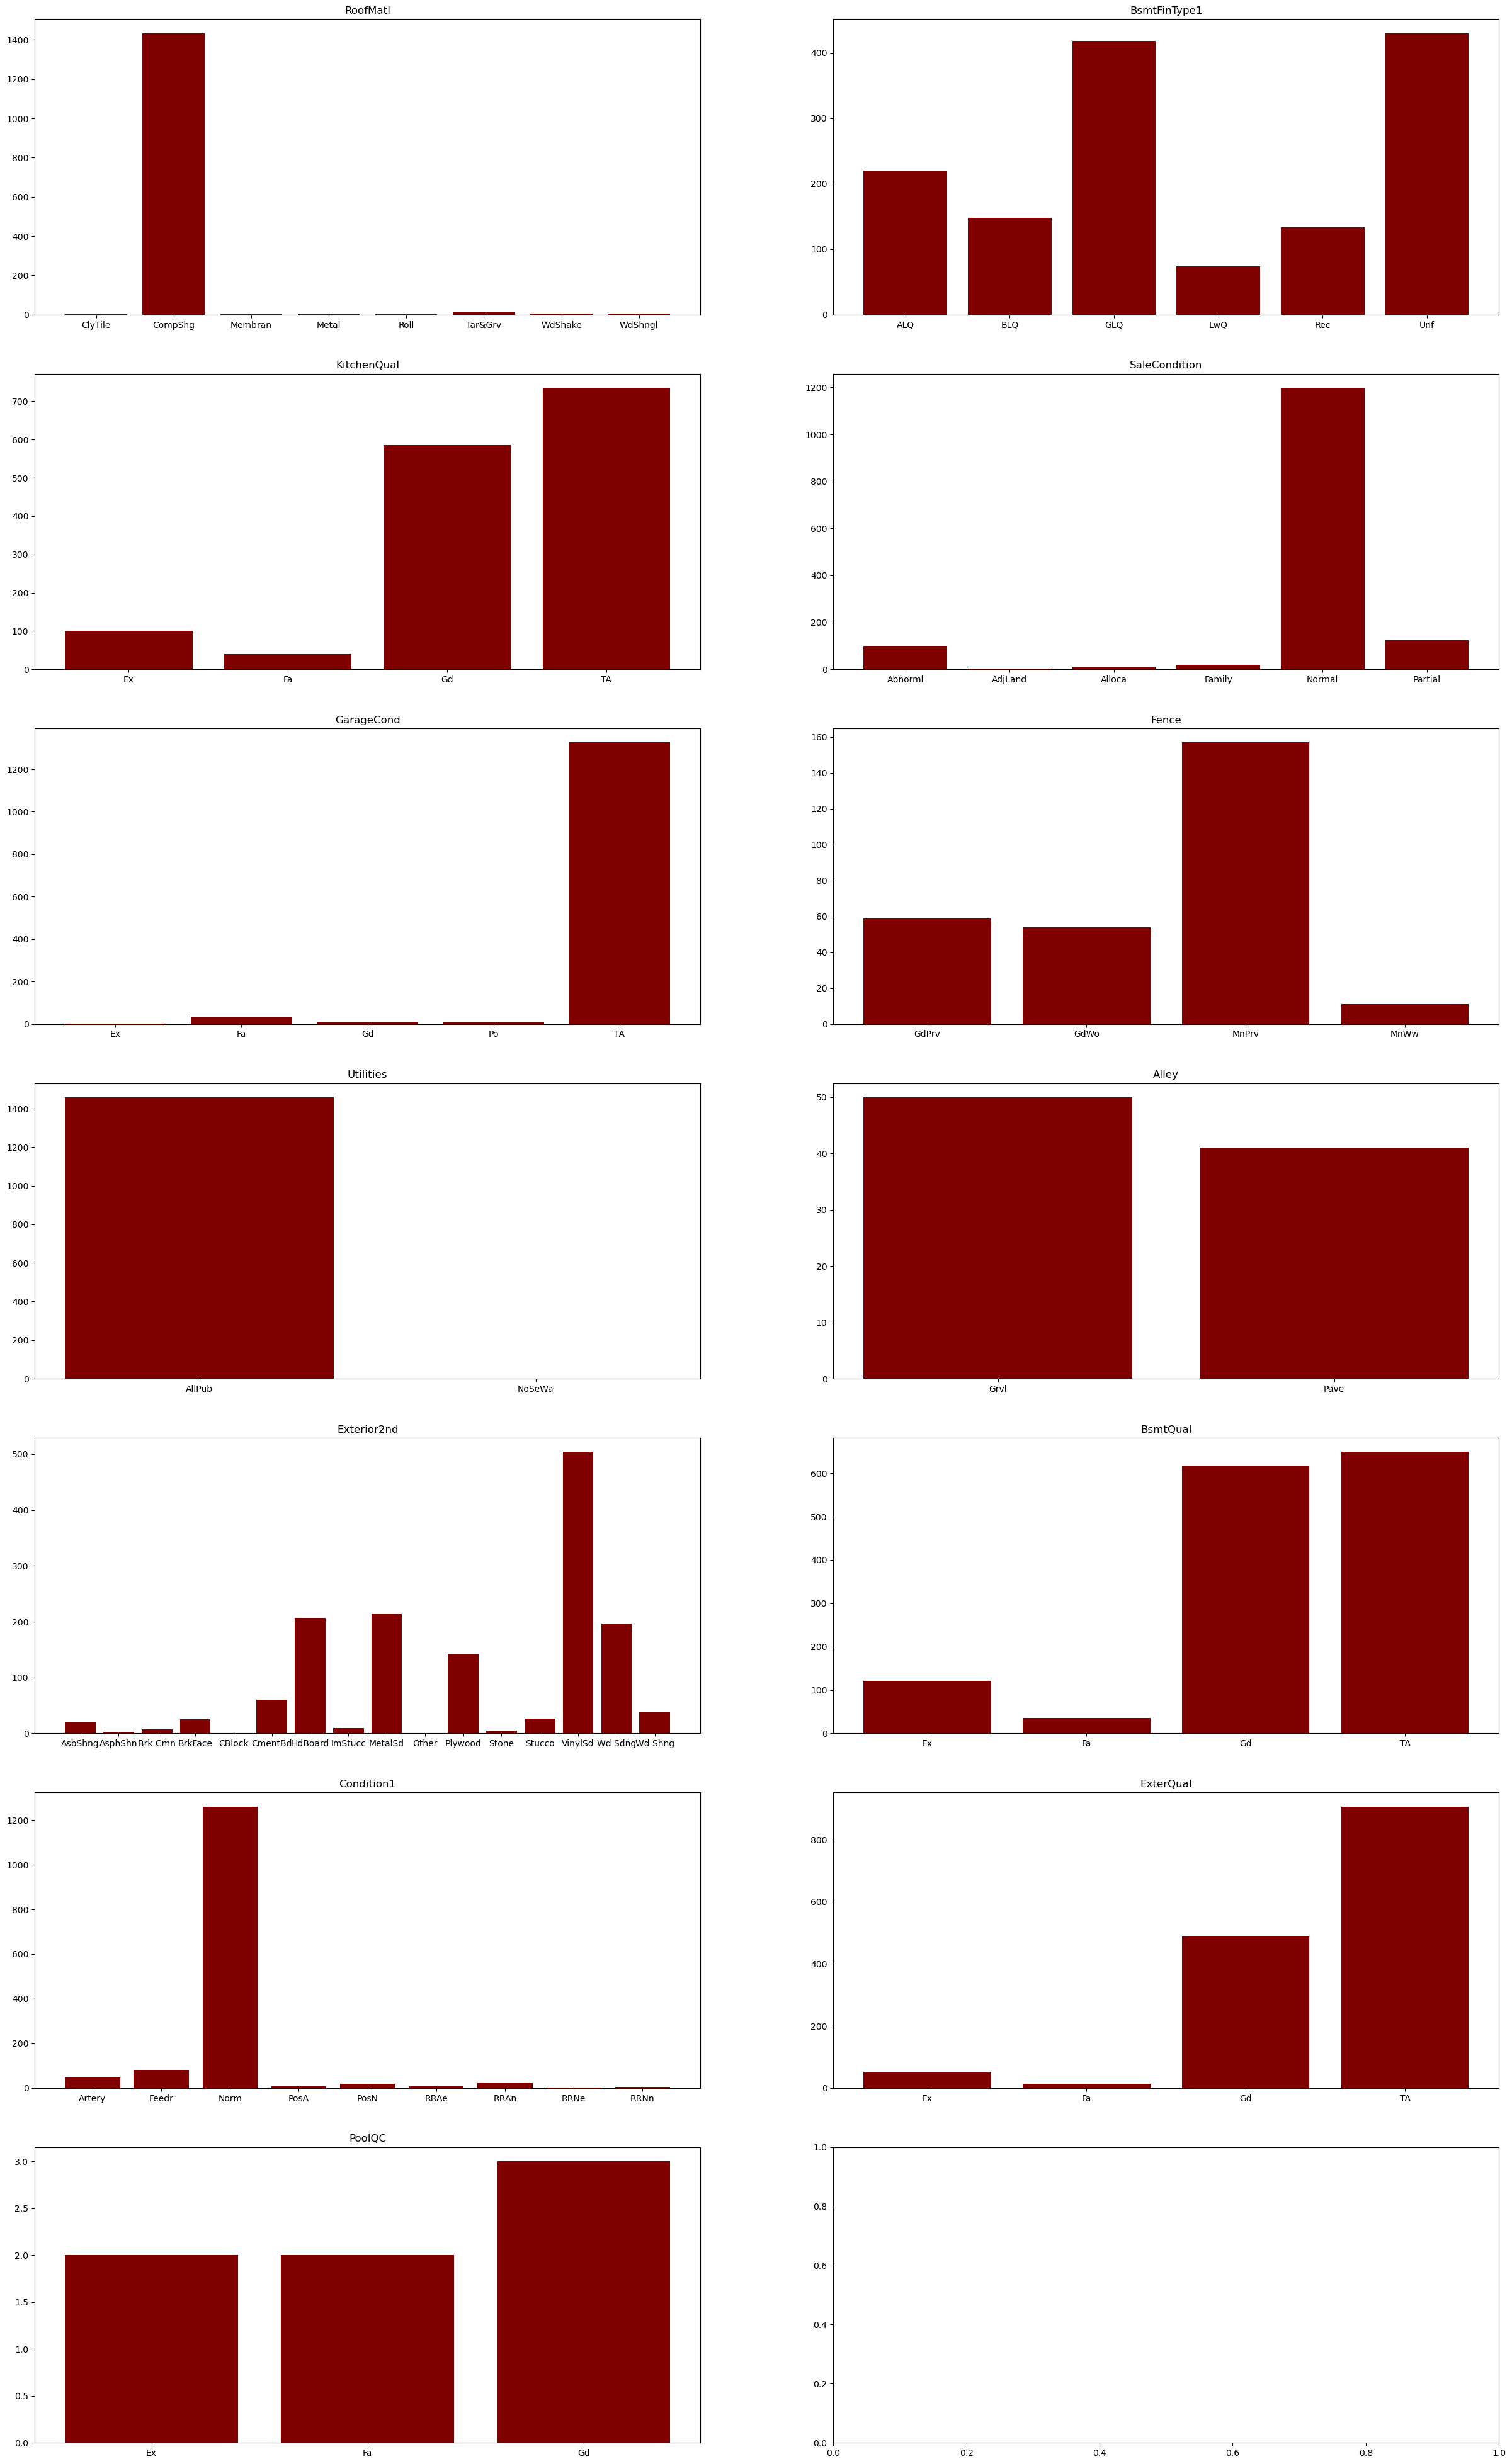

In [103]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[30:]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

# Preprocessing

## handling Null Values

In [104]:
train_data[num_cols].describe()

,BsmtFinSF2,MoSold,BsmtFinSF1,1stFlrSF,GarageYrBlt,TotRmsAbvGrd,BsmtFullBath,MSSubClass,GarageArea,GrLivArea,YrSold,OverallQual,EnclosedPorch,2ndFlrSF,HalfBath,YearBuilt,OpenPorchSF,BsmtHalfBath,WoodDeckSF,OverallCond,MiscVal,MasVnrArea,GarageCars,Fireplaces,LotArea,BsmtUnfSF,ScreenPorch,KitchenAbvGr,FullBath,SalePrice,BedroomAbvGr,LotFrontage,YearRemodAdd,PoolArea,3SsnPorch,LowQualFinSF,TotalBsmtSF
count,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,46.549315,6.321918,443.639726,1162.626712,1978.506164,6.517808,0.425342,56.897260,472.980137,1515.463699,2007.815753,6.099315,21.954110,346.992466,0.382877,1971.267808,46.660274,0.057534,94.244521,5.575342,43.489041,103.685262,1.767123,0.613014,10516.828082,567.240411,15.060959,1.046575,1.565068,180921.195890,2.866438,70.049958,1984.865753,2.758904,3.409589,5.844521,1057.429452
std,161.319273,2.703626,456.098091,386.587738,24.689725,1.625393,0.518911,42.300571,213.804841,525.480383,1.328095,1.382997,61.119149,436.528436,0.502885,30.202904,66.256028,0.238753,125.338794,1.112799,496.123024,181.066207,0.747315,0.644666,9981.264932,441.866955,55.757415,0.220338,0.550916,79442.502883,0.815778,24.284752,20.645407,40.177307,29.317331,48.623081,438.705324
min,0.000000,1.000000,0.000000,334.000000,1900.000000,2.000000,0.000000,20.000000,0.000000,334.000000,2006.000000,1.000000,0.000000,0.000000,0.000000,1872.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,34900.000000,0.000000,21.000000,1950.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,5.000000,0.000000,882.000000,1961.000000,5.000000,0.000000,20.000000,334.500000,1129.500000,2007.000000,5.000000,0.000000,0.000000,0.000000,1954.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,1.000000,0.000000,7553.500000,223.000000,0.000000,1.000000,1.000000,129975.000000,2.000000,59.000000,1967.000000,0.000000,0.000000,0.000000,795.750000
50%,0.000000,6.000000,383.500000,1087.000000,1980.000000,6.000000,0.000000,50.000000,480.000000,1464.000000,2008.000000,6.000000,0.000000,0.000000,0.000000,1973.000000,25.000000,0.000000,0.000000,5.000000,0.000000,0.000000,2.000000,1.000000,9478.500000,477.500000,0.000000,1.000000,2.000000,163000.000000,3.000000,69.000000,1994.000000,0.000000,0.000000,0.000000,991.500000
75%,0.000000,8.000000,712.250000,1391.250000,2002.000000,7.000000,1.000000,70.000000,576.000000,1776.750000,2009.000000,7.000000,0.000000,728.000000,1.000000,2000.000000,68.000000,0.000000,168.000000,6.000000,0.000000,166.000000,2.000000,1.000000,11601.500000,808.000000,0.000000,1.000000,2.000000,214000.000000,3.000000,80.000000,2004.000000,0.000000,0.000000,0.000000,1298.250000
max,1474.000000,12.000000,5644.000000,4692.000000,2010.000000,14.000000,3.000000,190.000000,1418.000000,5642.000000,2010.000000,10.000000,552.000000,2065.000000,2.000000,2010.000000,547.000000,2.000000,857.000000,9.000000,15500.000000,1600.000000,4.000000,3.000000,215245.000000,2336.000000,480.000000,3.000000,3.000000,755000.000000,8.000000,313.000000,2010.000000,738.000000,508.000000,572.000000,6110.000000


In [105]:
nulls_df = train_data.isna().sum().reset_index().rename(columns = {0:"Nulls_Count"})
nulls_df[nulls_df['Nulls_Count']> 0]

,index,Nulls_Count
3,LotFrontage,259
6,Alley,1369
25,MasVnrType,8
26,MasVnrArea,8
30,BsmtQual,37
31,BsmtCond,37
32,BsmtExposure,38
33,BsmtFinType1,37
35,BsmtFinType2,38
42,Electrical,1


In [106]:
#drop columns with 60% of data NULL
train_data = train_data.drop(columns=['Alley','PoolQC','Fence','MiscFeature','FireplaceQu'])

#drop small number of rows that have small number of null values using dropna
train_data = train_data.dropna(axis = 0, subset = ['GarageYrBlt', 'MasVnrArea', 'Electrical', 
                                                   'GarageFinish', 'GarageQual', 'GarageCond', 'GarageType',
                                                   'BsmtFinType2', 'BsmtFinType1', 'BsmtExposure', 'BsmtCond', 
                                                   'BsmtQual', 'MasVnrType'])
# fill nulls with the mean 
train_data['LotFrontage']=train_data['LotFrontage'].fillna(train_data['LotFrontage'].mean())

In [107]:
nulls_df = train_data.isna().sum().reset_index().rename(columns = { 0 : "Nulls_Count"})
nulls_df[nulls_df['Nulls_Count'] > 0]

,index,Nulls_Count


### Dropping any column which has 80% of values with the same value 

In [108]:
def dropping_var_with_same_value(count_df,df):
    highest_freq_percentage = (count_df['count']/df.count()[0]).\
                    reset_index().sort_values(by=['count'],ascending=
                    False).iloc[0,1]
    if highest_freq_percentage>= 0.8:
        print('we will drop the column ',count_df.columns[0])
        df = df.drop(columns = [count_df.columns[0]])
    return df

In [109]:
for idx in range(len(df_list)):
  train_data = dropping_var_with_same_value(df_list[idx], train_data)

we will drop the column  MSZoning
we will drop the column  BsmtCond
we will drop the column  RoofStyle
we will drop the column  GarageQual
we will drop the column  SaleType
we will drop the column  LandSlope
we will drop the column  Functional
we will drop the column  Heating
we will drop the column  BldgType
we will drop the column  LandContour
we will drop the column  PavedDrive
we will drop the column  Condition2
we will drop the column  ExterCond
we will drop the column  Electrical
we will drop the column  Street
we will drop the column  BsmtFinType2
we will drop the column  CentralAir
we will drop the column  RoofMatl
we will drop the column  SaleCondition
we will drop the column  GarageCond
we will drop the column  Utilities
we will drop the column  Condition1


### If we have 2 highly correlated features (corr > 0.7), we drop one of them (the variable which is less correlated to the response variable)

In [110]:
num_cols = list(set(train_data.describe().columns.to_list()) - set(["Id"]))
cat_cols = list(set(train_data.columns.to_list())-set(num_cols)-set(["Id"]))

In [111]:
num_cols_without_response_variable = list(set(num_cols) - set(['SalePrice']))
corr_matrix = train_data[num_cols_without_response_variable].corr()
corr_matrix

,BsmtFinSF2,MoSold,BsmtFinSF1,1stFlrSF,GarageYrBlt,TotRmsAbvGrd,BsmtFullBath,MSSubClass,GarageArea,GrLivArea,YrSold,OverallQual,EnclosedPorch,2ndFlrSF,HalfBath,YearBuilt,OpenPorchSF,BsmtHalfBath,WoodDeckSF,OverallCond,MiscVal,MasVnrArea,GarageCars,Fireplaces,LotArea,BsmtUnfSF,ScreenPorch,KitchenAbvGr,FullBath,BedroomAbvGr,LotFrontage,YearRemodAdd,PoolArea,3SsnPorch,LowQualFinSF,TotalBsmtSF
BsmtFinSF2,1.000000,-0.022039,-0.064855,0.094065,-0.092595,-0.042207,0.154980,-0.079329,-0.053411,-0.021993,0.032855,-0.086014,0.045668,-0.109254,-0.038494,-0.070403,0.004211,0.072813,0.061206,0.035698,0.006246,-0.083303,-0.080264,0.035643,0.110493,-0.233449,0.085865,-0.028278,-0.090448,-0.008179,0.040612,-0.085268,0.041148,-0.031475,0.007072,0.083184
MoSold,-0.022039,1.000000,-0.021242,0.024109,0.002463,0.041562,-0.022993,-0.016283,0.016794,0.051474,-0.144862,0.062641,-0.022169,0.042201,-0.010915,0.004396,0.060913,0.026507,0.031197,-0.011772,-0.008498,-0.013461,0.032796,0.055795,0.000118,0.031202,0.023331,0.036045,0.058436,0.049966,0.013494,0.014552,-0.035568,0.031341,-0.027212,0.000787
BsmtFinSF1,-0.064855,-0.021242,1.000000,0.450366,0.144611,0.046284,0.638094,-0.069053,0.284095,0.201974,0.023958,0.197441,-0.105669,-0.151876,-0.025251,0.224264,0.107561,0.057227,0.187178,-0.060068,0.007869,0.253015,0.197559,0.245323,0.210148,-0.552809,0.051906,-0.035623,0.045094,-0.119100,0.221452,0.099681,0.142708,0.026811,-0.051909,0.505000
1stFlrSF,0.094065,0.024109,0.450366,1.000000,0.237928,0.393786,0.251597,-0.258787,0.500071,0.554846,-0.011258,0.481978,-0.056003,-0.220279,-0.146494,0.263585,0.226615,-0.000064,0.233200,-0.144066,-0.014226,0.341001,0.440237,0.401929,0.288502,0.318097,0.083054,0.059242,0.367498,0.100643,0.410709,0.241889,0.134879,0.053159,-0.019860,0.893110
GarageYrBlt,-0.092595,0.002463,0.144611,0.237928,1.000000,0.148625,0.115751,0.082040,0.563860,0.224903,-0.002948,0.545835,-0.303525,0.060414,0.187518,0.825172,0.220879,-0.079362,0.224075,-0.336541,-0.031451,0.249750,0.590301,0.039871,-0.025700,0.180539,-0.077428,-0.125614,0.486013,-0.071565,0.063657,0.641585,-0.014934,0.027562,-0.037214,0.321500
TotRmsAbvGrd,-0.042207,0.041562,0.046284,0.393786,0.148625,1.000000,-0.052065,0.014514,0.368435,0.823491,-0.046446,0.442941,-0.003321,0.619275,0.357991,0.099415,0.249396,-0.016705,0.166052,-0.063883,0.026111,0.289758,0.404416,0.332325,0.185654,0.242020,0.058056,0.234984,0.547592,0.658923,0.320599,0.174660,0.088279,-0.011026,0.092241,0.297609
BsmtFullBath,0.154980,-0.022993,0.638094,0.251597,0.115751,-0.052065,1.000000,-0.011317,0.186558,0.028857,0.072016,0.083254,-0.046772,-0.184112,-0.058884,0.175108,0.072805,-0.159263,0.161982,-0.070089,-0.020704,0.078875,0.131403,0.133045,0.160687,-0.463986,0.017069,-0.012858,-0.084267,-0.161723,0.103836,0.099294,0.069236,0.000482,-0.029155,0.282031
MSSubClass,-0.079329,-0.016283,-0.069053,-0.258787,0.082040,0.014514,-0.011317,1.000000,-0.070278,0.068782,-0.021591,0.051690,-0.022598,0.306709,0.197520,0.056456,-0.000359,-0.000151,-0.010175,-0.098153,-0.021512,0.031333,0.006872,-0.024752,-0.134158,-0.141025,-0.022748,0.239177,0.117720,-0.065699,-0.358317,0.038513,0.010199,-0.041391,0.019990,-0.263613
GarageArea,-0.053411,0.016794,0.284095,0.500071,0.563860,0.368435,0.186558,-0.070278,1.000000,0.477868,-0.022030,0.530092,-0.111119,0.124564,0.126283,0.443854,0.269498,-0.044979,0.204033,-0.204905,-0.028575,0.367237,0.832166,0.203763,0.168630,0.195401,0.018501,0.035487,0.424693,0.089036,0.332318,0.386213,0.062077,0.029688,0.013996,0.511475
GrLivArea,-0.021993,0.051474,0.201974,0.554846,0.224903,0.823491,0.028857,0.068782,0.477868,1.000000,-0.039424,0.594470,0.012779,0.685710,0.415221,0.189146,0.341273,-0.020012,0.241277,-0.093843,0.001054,0.392006,0.483943,0.458109,0.255445,0.222438,0.095358,0.100521,0.625953,0.510088,0.363011,0.276580,0.176463,0.018512,0.101100,0.460778


In [112]:
for row_idx in range(corr_matrix.values.shape[0]):
    for col_idx in range(row_idx+1,corr_matrix.values.shape[0]):
        if (np.abs(corr_matrix.values[row_idx,col_idx])>0.7):
            var_row_corr_with_response = np.abs(np.corrcoef(train_data['SalePrice'],
                                                           train_data[num_cols_without_response_variable[row_idx]])[0,1])
            var_col_corr_with_response = np.abs(np.corrcoef(train_data['SalePrice'],
                                                           train_data[num_cols_without_response_variable[col_idx]])[0,1])
            if var_row_corr_with_response > var_col_corr_with_response:
                print('drop the column: ',num_cols_without_response_variable[col_idx])
                train_data = train_data.drop(columns=[num_cols_without_response_variable[col_idx]])
            else:
                print('drop the column: ',num_cols_without_response_variable[row_idx])
                train_data = train_data.drop(columns=[num_cols_without_response_variable[row_idx]])
                

drop the column:  TotalBsmtSF
drop the column:  GarageYrBlt
drop the column:  TotRmsAbvGrd
drop the column:  GarageArea


In [113]:
num_cols = list(set(train_data.describe().columns.to_list())-set('Id'))
cat_cols = list(set(train_data.columns.to_list())-set(num_cols)-set(['Id']))

In [114]:
len(num_cols)

34

## Clip Outliers

In [115]:
def clip_outliers(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    Upper_Bound = Q3 + 1.5 * IQR
    Lower_Bound = Q1 - 1.5 * IQR
    
    df[col] = df[col].clip(lower=Lower_Bound, upper=Upper_Bound)
    
    return df

actual_num_cols = [col for col in num_cols if col in train_data.columns]

for col in actual_num_cols:
    train_data = clip_outliers(train_data, col)
print("Done clamping outliers successfully!")

Done clamping outliers successfully!


In [116]:
num_cols = list(set(train_data.describe().columns.to_list())-set('Id'))
cat_cols = list(set(train_data.columns.to_list())-set(num_cols)-set(['Id']))

## log-transform any highly skewed variable

In [117]:
for col in num_cols:
    sk = train_data[col].skew()
    if sk >= 1 or sk <= -1:
        
        train_data[col] = np.where(train_data[col] >= 0, 
                                   np.log1p(train_data[col]), 
                                   train_data[col])